In [1]:
import os
from typing import Annotated, TypedDict, Literal, Optional, List, Dict
from datetime import datetime

from langgraph.graph import StateGraph, START, END
from langgraph.types import Command, interrupt
from langgraph.graph.message import add_messages

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage

from langgraph.checkpoint.memory import MemorySaver

from dotenv import load_dotenv
from loguru import logger

load_dotenv()


True

In [2]:
llm = ChatOpenAI(model="gpt-4o-mini", api_key=os.getenv("OPENAI_API_KEY"))

template = """When asked to ask the user a question, respond with only the question itself, without any additional text or context.

When asked to say goodbye to the user, respond with only a goodbye message.


More instructions:
- Do not add sure to your response.
- Do not add any additional text or context to your response.
- Do not add any additional questions to your response.

For all other interactions:
Your job is to get information from a user about what type of prompt template they want to create.
"""


In [3]:
def get_messages_info(messages):
    return [SystemMessage(content=template)] + messages

# 1. Define a simplified driver state structure
class DriverState(TypedDict):
    carrier_confirmed: bool
    ask_carrier_confirmed: bool
    messages: Annotated[list, add_messages]
    isRunning: Optional[bool] = None
    current_query: Optional[str] = None
    departed: bool
    ask_departed: bool

def ask_courier_confirmation(state: DriverState):
    'Ask if the courier has confirmed the pickup.'
    LLM_query = llm.invoke(get_messages_info(['Ask if the courier has confirmed the pickup.']))
    print(LLM_query.content)
    return {**state, "ask_carrier_confirmed": True, "current_query": LLM_query.content}


def get_courier_confirmation(state: DriverState):
    'Get the courier confirmation from the user.'

    print("get_courier_confirmation")

    human_response = interrupt({"query": state["current_query"]})

    # print(human_response)
    # courier_confirmation = human_response["data"]

    msg = llm.invoke(f'''See the user prompt and check if there is a courier confirmation 
                     Conditons:
                     - If there is a courier confirmation and it is yes, return True
                     - If there is no courier confirmation or the courier confirmation is not yes, return False
                     
                     User prompt: {human_response}''')
    
    logger.debug(msg.content)
    
    if 'True' in msg.content:
        return {
             **state,
            "messages": [*state["messages"], state["current_query"], HumanMessage(content=human_response)],
            "carrier_confirmed": True
        }
    else:
        return {
             **state,
            "messages": [*state["messages"], state["current_query"], HumanMessage(content=human_response)],
            "carrier_confirmed": False
        }

    
def goodBye(state: DriverState):
    'Say good bye to the user.'
    msg = llm.invoke('Say good bye to the user.')
    print(msg.content)
    return {**state, "isRunning": False}

def origin(state: DriverState):
    return state
    
def ask_departed(state: DriverState):
    LLM_query = llm.invoke(get_messages_info(['Ask if the courier has departed.']))
    print(LLM_query.content)
    return {**state, "ask_departed": True, "current_query": LLM_query.content}

def get_departed(state: DriverState):
    human_response = interrupt({"query": state["current_query"]})
    # print(human_response)
    # return {**state, "messages": [*state["messages"], state["current_query"], HumanMessage(content=human_response)], "departed": True}

    msg = llm.invoke(f'''See the user prompt and check if courier has departed
                     Conditons:
                     - If courier has departed and it is yes, return True
                     - If courier has not departed or the courier has departed is not yes, return False
                     
                     User prompt: {human_response}''')
    
    logger.debug(msg.content)
    
    if 'True' in msg.content:
        return {
             **state,
            "messages": [*state["messages"], state["current_query"], HumanMessage(content=human_response)],
            "departed": True
        }
    else:
        return {
             **state,
            "messages": [*state["messages"], state["current_query"], HumanMessage(content=human_response)],
            "departed": False
        }

def origin_router(state: DriverState):
    if not state["ask_carrier_confirmed"]:    
        return "ask_courier_confirmation"
    elif not state["carrier_confirmed"]:
        return "get_courier_confirmation"
    elif not state["ask_departed"]:
        return "ask_departed_node"
    elif not state["departed"]:
        return "get_departed_node"
    else:
        return "goodBye"


In [4]:
# 3. Build the graph
def build_driver_graph():
    graph_builder = StateGraph(DriverState)
    
    # Add all the nodes
    graph_builder.add_node("origin", origin)
    graph_builder.add_node("ask_courier_confirmation", ask_courier_confirmation)
    graph_builder.add_node("get_courier_confirmation", get_courier_confirmation)
    graph_builder.add_node("ask_departed_node", ask_departed)
    graph_builder.add_node("get_departed_node", get_departed)
    graph_builder.add_node("goodBye", goodBye)

    graph_builder.add_edge(START, "origin")

    graph_builder.add_conditional_edges(
        "origin",
        origin_router,
        {
            "ask_courier_confirmation": "ask_courier_confirmation",
            "get_courier_confirmation": "get_courier_confirmation",
            "ask_departed_node": "ask_departed_node",
            "get_departed_node": "get_departed_node",
            "goodBye": "goodBye"
        }
        
    )    

    # graph_builder.add_edge("ask_courier_confirmation", "get_courier_confirmation")
    graph_builder.add_edge("get_courier_confirmation", "goodBye")
    graph_builder.add_edge("goodBye", END)

    memory = MemorySaver()
    graph = graph_builder.compile(checkpointer=memory)

    return graph


# Running the Graph

In [5]:
state = {
    "carrier_confirmed": False,
    "ask_carrier_confirmed": False,
    "ask_departed": False,
    "departed": False,
    "messages": [HumanMessage(content="Hello, how are you?")],
    "current_query": None
}

driver_graph = build_driver_graph()

In [6]:
result = driver_graph.invoke(state, config = {"configurable": {"thread_id": "1"}})
# state = process_driver_flow(state)

result

Has the courier confirmed the pickup?


{'carrier_confirmed': False,
 'ask_carrier_confirmed': True,
 'messages': [HumanMessage(content='Hello, how are you?', additional_kwargs={}, response_metadata={}, id='e65b8c49-a5ac-4d97-a430-79b33a6eb6e1')],
 'current_query': 'Has the courier confirmed the pickup?',
 'departed': False,
 'ask_departed': False}

In [7]:
for event in driver_graph.stream(result, config = {"configurable": {"thread_id": "1"}}):
    print(event)
    print()

{'origin': {'carrier_confirmed': False, 'ask_carrier_confirmed': True, 'messages': [HumanMessage(content='Hello, how are you?', additional_kwargs={}, response_metadata={}, id='e65b8c49-a5ac-4d97-a430-79b33a6eb6e1')], 'current_query': 'Has the courier confirmed the pickup?', 'departed': False, 'ask_departed': False}}

get_courier_confirmation
{'__interrupt__': (Interrupt(value={'query': 'Has the courier confirmed the pickup?'}, resumable=True, ns=['get_courier_confirmation:8f813ee2-576c-866e-8261-2bbc1ae84089']),)}



In [8]:
thread = {"configurable": {"thread_id": "1"}}

for event in driver_graph.stream(
    Command(resume="yes"), 
    config = thread
):
    print(event)
    print()

get_courier_confirmation


2025-04-25 19:31:57.685 | DEBUG    | __main__:get_courier_confirmation:38 - True


{'get_courier_confirmation': {'carrier_confirmed': True, 'ask_carrier_confirmed': True, 'messages': [HumanMessage(content='Hello, how are you?', additional_kwargs={}, response_metadata={}, id='e65b8c49-a5ac-4d97-a430-79b33a6eb6e1'), 'Has the courier confirmed the pickup?', HumanMessage(content='yes', additional_kwargs={}, response_metadata={}, id='6819e6c3-ddcf-4aad-988a-8329b1bc53b4')], 'current_query': 'Has the courier confirmed the pickup?', 'departed': False, 'ask_departed': False}}

Goodbye! If you ever need anything in the future, feel free to reach out. Take care!
{'goodBye': {'carrier_confirmed': True, 'ask_carrier_confirmed': True, 'messages': [HumanMessage(content='Hello, how are you?', additional_kwargs={}, response_metadata={}, id='e65b8c49-a5ac-4d97-a430-79b33a6eb6e1'), HumanMessage(content='Has the courier confirmed the pickup?', additional_kwargs={}, response_metadata={}, id='a213ae4a-e19c-4c2d-974c-23a6473dc3eb'), HumanMessage(content='yes', additional_kwargs={}, respon

In [9]:
state = driver_graph.get_state(thread).values
state

{'carrier_confirmed': True,
 'ask_carrier_confirmed': True,
 'messages': [HumanMessage(content='Hello, how are you?', additional_kwargs={}, response_metadata={}, id='e65b8c49-a5ac-4d97-a430-79b33a6eb6e1'),
  HumanMessage(content='Has the courier confirmed the pickup?', additional_kwargs={}, response_metadata={}, id='a213ae4a-e19c-4c2d-974c-23a6473dc3eb'),
  HumanMessage(content='yes', additional_kwargs={}, response_metadata={}, id='6819e6c3-ddcf-4aad-988a-8329b1bc53b4')],
 'isRunning': False,
 'current_query': 'Has the courier confirmed the pickup?',
 'departed': False,
 'ask_departed': False}

In [10]:
for event in driver_graph.stream(
    state,
    config = thread
):
    print(event)
    print()

{'origin': {'carrier_confirmed': True, 'ask_carrier_confirmed': True, 'messages': [HumanMessage(content='Hello, how are you?', additional_kwargs={}, response_metadata={}, id='e65b8c49-a5ac-4d97-a430-79b33a6eb6e1'), HumanMessage(content='Has the courier confirmed the pickup?', additional_kwargs={}, response_metadata={}, id='a213ae4a-e19c-4c2d-974c-23a6473dc3eb'), HumanMessage(content='yes', additional_kwargs={}, response_metadata={}, id='6819e6c3-ddcf-4aad-988a-8329b1bc53b4')], 'isRunning': False, 'current_query': 'Has the courier confirmed the pickup?', 'departed': False, 'ask_departed': False}}

Has the courier departed?
{'ask_departed_node': {'carrier_confirmed': True, 'ask_carrier_confirmed': True, 'messages': [HumanMessage(content='Hello, how are you?', additional_kwargs={}, response_metadata={}, id='e65b8c49-a5ac-4d97-a430-79b33a6eb6e1'), HumanMessage(content='Has the courier confirmed the pickup?', additional_kwargs={}, response_metadata={}, id='a213ae4a-e19c-4c2d-974c-23a6473dc3

In [11]:
state = driver_graph.get_state(thread).values
state

{'carrier_confirmed': True,
 'ask_carrier_confirmed': True,
 'messages': [HumanMessage(content='Hello, how are you?', additional_kwargs={}, response_metadata={}, id='e65b8c49-a5ac-4d97-a430-79b33a6eb6e1'),
  HumanMessage(content='Has the courier confirmed the pickup?', additional_kwargs={}, response_metadata={}, id='a213ae4a-e19c-4c2d-974c-23a6473dc3eb'),
  HumanMessage(content='yes', additional_kwargs={}, response_metadata={}, id='6819e6c3-ddcf-4aad-988a-8329b1bc53b4')],
 'isRunning': False,
 'current_query': 'Has the courier departed?',
 'departed': False,
 'ask_departed': True}

In [12]:
for event in driver_graph.stream(
    state,
    config = thread
):
    print(event)
    print()

{'origin': {'carrier_confirmed': True, 'ask_carrier_confirmed': True, 'messages': [HumanMessage(content='Hello, how are you?', additional_kwargs={}, response_metadata={}, id='e65b8c49-a5ac-4d97-a430-79b33a6eb6e1'), HumanMessage(content='Has the courier confirmed the pickup?', additional_kwargs={}, response_metadata={}, id='a213ae4a-e19c-4c2d-974c-23a6473dc3eb'), HumanMessage(content='yes', additional_kwargs={}, response_metadata={}, id='6819e6c3-ddcf-4aad-988a-8329b1bc53b4')], 'isRunning': False, 'current_query': 'Has the courier departed?', 'departed': False, 'ask_departed': True}}

{'__interrupt__': (Interrupt(value={'query': 'Has the courier departed?'}, resumable=True, ns=['get_departed_node:7f53ec50-b8b1-bfd6-62a4-efc24892c8ce']),)}



In [13]:
thread = {"configurable": {"thread_id": "1"}}

for event in driver_graph.stream(
    Command(resume="no"), 
    config = thread
):
    print(event)
    print()

2025-04-25 19:32:00.512 | DEBUG    | __main__:get_departed:80 - Based on the user prompt "no," which indicates that the courier has not departed, the output should be False.


{'get_departed_node': {'carrier_confirmed': True, 'ask_carrier_confirmed': True, 'messages': [HumanMessage(content='Hello, how are you?', additional_kwargs={}, response_metadata={}, id='e65b8c49-a5ac-4d97-a430-79b33a6eb6e1'), HumanMessage(content='Has the courier confirmed the pickup?', additional_kwargs={}, response_metadata={}, id='a213ae4a-e19c-4c2d-974c-23a6473dc3eb'), HumanMessage(content='yes', additional_kwargs={}, response_metadata={}, id='6819e6c3-ddcf-4aad-988a-8329b1bc53b4'), 'Has the courier departed?', HumanMessage(content='no', additional_kwargs={}, response_metadata={}, id='dfa5f70c-3bde-44a8-8a72-af9be0245bf6')], 'isRunning': False, 'current_query': 'Has the courier departed?', 'departed': False, 'ask_departed': True}}



In [14]:
state = driver_graph.get_state(thread).values
state

{'carrier_confirmed': True,
 'ask_carrier_confirmed': True,
 'messages': [HumanMessage(content='Hello, how are you?', additional_kwargs={}, response_metadata={}, id='e65b8c49-a5ac-4d97-a430-79b33a6eb6e1'),
  HumanMessage(content='Has the courier confirmed the pickup?', additional_kwargs={}, response_metadata={}, id='a213ae4a-e19c-4c2d-974c-23a6473dc3eb'),
  HumanMessage(content='yes', additional_kwargs={}, response_metadata={}, id='6819e6c3-ddcf-4aad-988a-8329b1bc53b4'),
  HumanMessage(content='Has the courier departed?', additional_kwargs={}, response_metadata={}, id='41f60fa7-e2e1-427b-9ed2-f7664fd6947b'),
  HumanMessage(content='no', additional_kwargs={}, response_metadata={}, id='dfa5f70c-3bde-44a8-8a72-af9be0245bf6')],
 'isRunning': False,
 'current_query': 'Has the courier departed?',
 'departed': False,
 'ask_departed': True}

In [15]:
for event in driver_graph.stream(
    state,
    config = thread
):
    print(event)
    print()

{'origin': {'carrier_confirmed': True, 'ask_carrier_confirmed': True, 'messages': [HumanMessage(content='Hello, how are you?', additional_kwargs={}, response_metadata={}, id='e65b8c49-a5ac-4d97-a430-79b33a6eb6e1'), HumanMessage(content='Has the courier confirmed the pickup?', additional_kwargs={}, response_metadata={}, id='a213ae4a-e19c-4c2d-974c-23a6473dc3eb'), HumanMessage(content='yes', additional_kwargs={}, response_metadata={}, id='6819e6c3-ddcf-4aad-988a-8329b1bc53b4'), HumanMessage(content='Has the courier departed?', additional_kwargs={}, response_metadata={}, id='41f60fa7-e2e1-427b-9ed2-f7664fd6947b'), HumanMessage(content='no', additional_kwargs={}, response_metadata={}, id='dfa5f70c-3bde-44a8-8a72-af9be0245bf6')], 'isRunning': False, 'current_query': 'Has the courier departed?', 'departed': False, 'ask_departed': True}}

{'__interrupt__': (Interrupt(value={'query': 'Has the courier departed?'}, resumable=True, ns=['get_departed_node:4e5cc476-18c9-266f-2805-17eb36b9966f']),)}

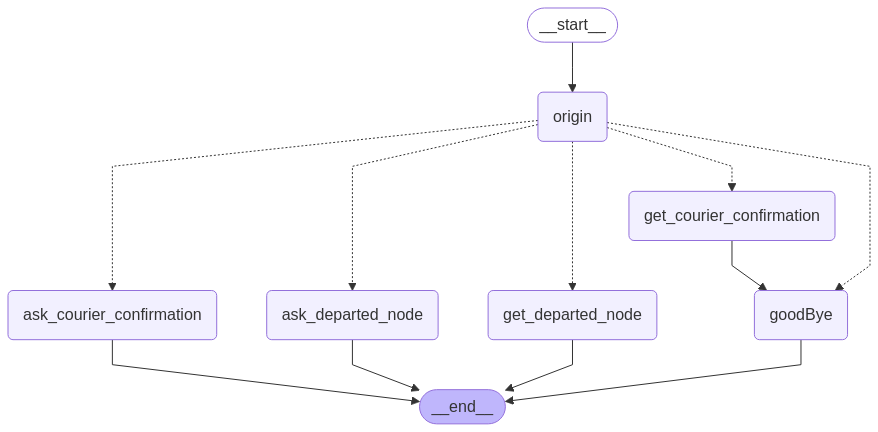

In [16]:
from IPython.display import Image, display

try:
    display(Image(driver_graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

# Utility functions

In [17]:
def format_response(response, state: DriverState):
    """Format the response for the UI"""
    message = ""
    
    # Log the exact response for debugging
    logger.debug(f"Raw response type: {type(response)}")
    logger.debug(f"Raw response: {response}")
    
    try:
        # Handle dictionary responses
        if isinstance(response, dict):
            # Handle interrupt messages
            if '__interrupt__' in response:
                interrupt_tuple = response['__interrupt__']
                if isinstance(interrupt_tuple, tuple) and len(interrupt_tuple) > 0:
                    interrupt_obj = interrupt_tuple[0]
                    if hasattr(interrupt_obj, 'value') and isinstance(interrupt_obj.value, dict):
                        message = interrupt_obj.value.get('query', '')
                        logger.debug(f"Extracted query from interrupt: {message}")
            # Handle goodbye messages
            elif 'goodBye' in response:
                message = "Goodbye! Thank you for using our service."
                logger.debug("Generated goodbye message")
        
        # Handle string responses (fallback)
        elif isinstance(response, str):
            message = response
            logger.debug(f"Using string response directly: {message}")

    except Exception as e:
        logger.error(f"Error formatting response: {e}")
        message = str(response)

    # If we still don't have a valid message, use a safe fallback
    if not message:
        logger.warning(f"Failed to extract message, using raw response: {response}")
        message = str(response)

    logger.debug(f"Final formatted message: {message}")
    
    return {
        "message": message,
        "state": {
            "carrier_confirmed": state["carrier_confirmed"],
            "departed": state["departed"],
            "current_step": "confirmation" if not state["carrier_confirmed"] else "departure" if not state["departed"] else "complete"
        }
    }

def process_chat_sequence(state: DriverState, user_message: Optional[str] = None):
    """
    Process the chat sequence following the pattern:
    1. interrupt - get question for user
    2. update state - handle user's response
    3. simple query - process current state
    4. new interrupt - prepare next question
    5. repeat
    """
    thread = {"configurable": {"thread_id": "1"}}
    
    if user_message is None:
        # Initial flow - get first interrupt
        result = driver_graph.invoke(state, config=thread)
        response = None
        for event in driver_graph.stream(result, config=thread):
            response = event
        return format_response(response, state)
    else:
        # 1. Handle interrupt (user's response)
        result = driver_graph.invoke(Command(resume=user_message), config=thread)
        
        # 2. Update state
        state = driver_graph.get_state(thread).values
        
        # 3. Process current state
        response = None
        for event in driver_graph.stream(state, config=thread):
            if event:
                response = event
                
        # 4. Get new interrupt/next state
        if not state["carrier_confirmed"] or not state["departed"]:
            result = driver_graph.invoke(state, config=thread)
            for event in driver_graph.stream(result, config=thread):
                if event:
                    response = event
        
        return format_response(response, state)

def initialize_chat():
    """Initialize a new chat session with default state"""
    initial_state = {
        "carrier_confirmed": False,
        "ask_carrier_confirmed": False,
        "ask_departed": False,
        "departed": False,
        "messages": [HumanMessage(content="Hello, how are you?")],
        "current_query": None
    }
    return initial_state

def get_current_state():
    """Get the current state of the conversation"""
    thread = {"configurable": {"thread_id": "1"}}
    return driver_graph.get_state(thread).values

# Example usage in the notebook:
"""
# Initialize chat
state = initialize_chat()

# Get first interrupt/question
response = process_chat_sequence(state)
print("Bot:", response)

# Send user response and get next interrupt
response = process_chat_sequence(state, "yes")
print("Bot:", response)

# Continue conversation...
response = process_chat_sequence(state, "yes")
print("Bot:", response)
"""





'\n# Initialize chat\nstate = initialize_chat()\n\n# Get first interrupt/question\nresponse = process_chat_sequence(state)\nprint("Bot:", response)\n\n# Send user response and get next interrupt\nresponse = process_chat_sequence(state, "yes")\nprint("Bot:", response)\n\n# Continue conversation...\nresponse = process_chat_sequence(state, "yes")\nprint("Bot:", response)\n'